# Diseño de filtros para señales EMG y ECG
## 1. Filtros EMG:
### 1.1 Señal EMG 1: Elevación Trapecio descendente (superior) (aun no terminado)

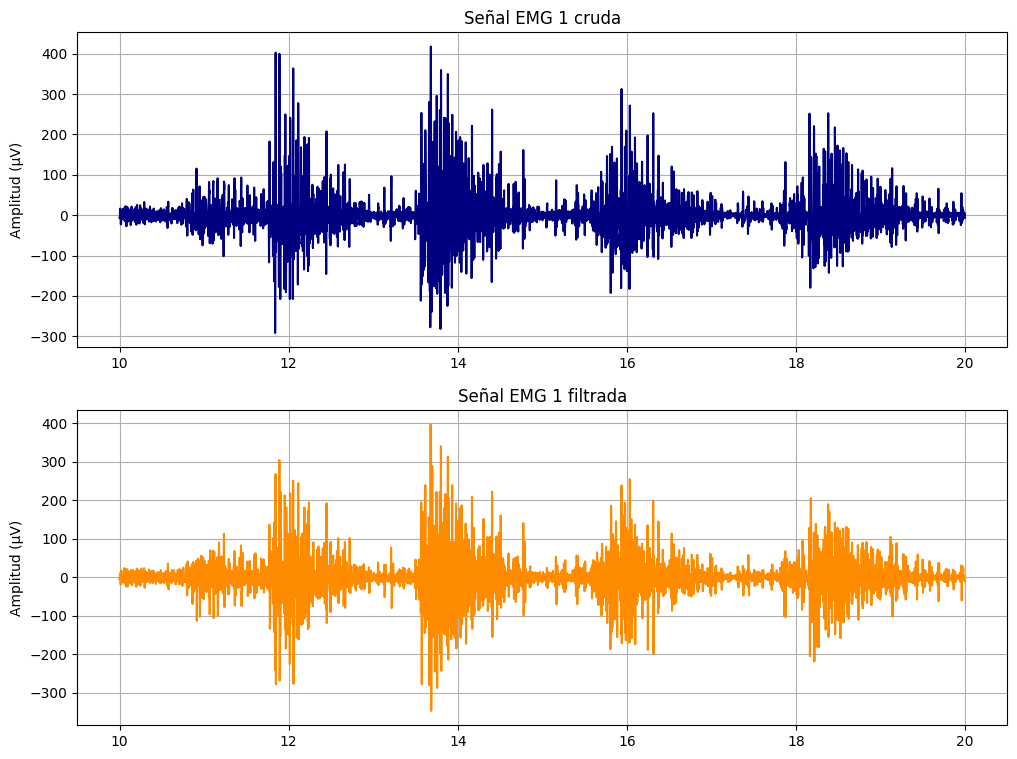

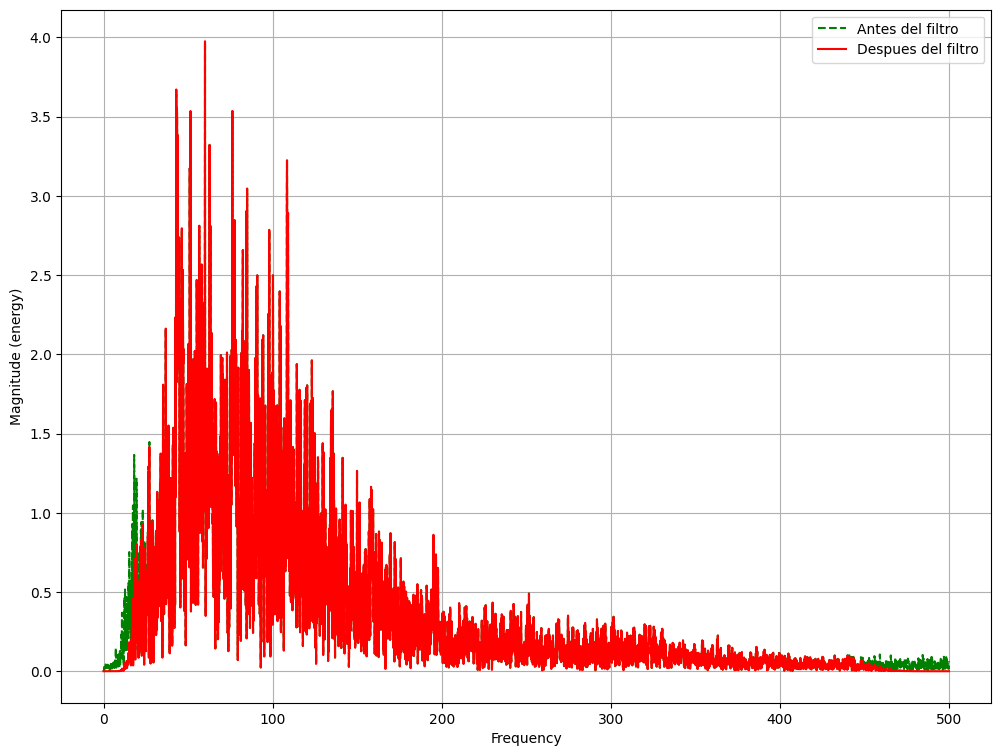

<Figure size 640x480 with 0 Axes>

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import firwin, lfilter, welch
from tqdm import tqdm

# Parámetros y carga
Fs = 1000  # Hz
emg1 = np.loadtxt("Señales/EMG_1.txt", usecols=[-1])
t = np.arange(len(emg1)) / Fs


# Movimiento
inicio = int(10 * Fs)
fin    = int(20 * Fs)
x = emg1[inicio:fin] # Movimiento
tt = t[inicio:fin]

# Rectificar y Welch
x = x - x.mean()        # quitar DC
# x_rect = np.abs(x)      # rectificación

# Cargar coeficientes del filtro IIR diseñado en pyfda
f1 = pd.read_csv("EMG_1.1_coef.csv", names=["b", "a"])
f1.head()
b = f1["b"].to_numpy()
a = f1["a"].to_numpy()

# Filtrado
y = lfilter(b, a, x)

plt.figure(figsize=(12, 9))

# Señal cruda
plt.subplot(2, 1, 1)
plt.plot(tt, x, color="navy")
plt.title("Señal EMG 1 cruda")
plt.ylabel("Amplitud (µV)")
plt.grid(True)

# Señal filtrada
plt.subplot(2, 1, 2)
plt.plot(tt, y, color="darkorange")
plt.title("Señal EMG 1 filtrada")
plt.ylabel("Amplitud (µV)")
plt.grid(True)

plt.show()

# Frecuencias
plt.figure(figsize=(12, 9))

plt.magnitude_spectrum(x, Fs=Fs, color="green", ls="--", label="Antes del filtro")
plt.magnitude_spectrum(y, Fs=Fs, color="red", label="Despues del filtro")

plt.legend()
plt.grid("--")
plt.show()

plt.tight_layout()
